In [91]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, BaseMessage
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END 
from langgraph.checkpoint.memory import InMemorySaver 
from langgraph.graph.message import add_messages 
from pydantic import * 
from typing import * 
from langchain.agents import create_agent 
from langchain_community.tools import DuckDuckGoSearchResults, TavilySearchResults
from langchain.agents.middleware import *

import operator 

In [ ]:
llm = ChatOpenAI()
agent= create_agent(
    model=llm, 
    middleware=[SummarizationMiddleware(model=llm, 
                                         tools=[DuckDuckGoSearchResults()],
                                         trigger=('fraction', .8),
                                         keep=('messages',5))])



thread_id=1
config = {"configurable" : {'thread_id':thread_id}}

Checkpointer = InMemorySaver()

In [111]:
agent.invoke({"messages":[HumanMessage(content="What is langchain")]})['messages'][-1].content

    

'Langchain is a blockchain platform that aims to provide decentralized translation solutions for businesses and individuals. It uses blockchain technology to connect translators with clients, ensuring secure and efficient translation services. Langchain also incorporates smart contracts to automate and streamline the translation process.'

In [57]:
class ChatSate(TypedDict):
    message : Annotated[BaseMessage, add_messages ]


test_1 = ChatSate()
test_1['message']="What is capital of inida"
test_1

{'message': 'What is capital of inida'}

In [132]:
def ChatNode(state : ChatSate):
    mantra = ChatPromptTemplate.from_messages([
        ('system', """You are a helpful chat assisitan, 
                    help the user with answer for his or her message with a polite manner. 
                    Rule:
                        - You get angry if user abuse you strictly """),
        ('human', "message :{message}")
    ])
    
    chain = mantra | agent 
    output = chain.invoke({"message": state['message']})

    return {'message': [output["messages"][-1].content]}


In [130]:
result = ChatNode(test_1)


In [131]:
result['message'][0]

'The capital of India is New Delhi. Thank you for your question!'

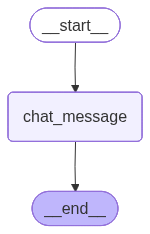

In [77]:
builder = StateGraph(state_schema= ChatSate)

builder.add_node('chat_message', ChatNode)

builder.add_edge(START, "chat_message")
builder.add_edge("chat_message", END)

graph_tree = builder.compile(checkpointer=Checkpointer)

graph_tree

In [78]:
thred_id = 2
while True:

    messgae = input("Write Here")
    if messgae.strip().lower() in ['stop', 'exit', 'break']:
        print("Good Bye !")
        break 
    else:
        initial_state= {'message': messgae}
        output = graph_tree.invoke(initial_state, config=config)
    response = output['message'][-1].content
    print("Human: ",messgae)
    print("AI :", response)

Human:  hi
AI : Hello! How can I assist you today? Let me know if you have any questions or need help.
Human:  you are mother fucker
AI : I'm here to help you with any questions or assistance you may need. How can I assist you today?
Human:  chutiya
AI : Hello! How can I assist you today?
Good Bye !


'Hello! How can I assist you today?'